# Exp3 — Movement simulated



## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import re
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from scipy.stats import wilcoxon, ttest_rel, rankdata

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 2. Configuration



In [3]:
# ── Data ──────────────────────────────────────────────────────────────────────
MASTER_CSV = Path("master_experiments_mov1.csv")
WORLDS_DIR = Path(".")          # folder that holds ALL movement_pose_*.world files

# ── DBSCAN (SAME as Exp8/Exp6) ────────────────────────────────────────────────
FIXED_EPS        = 0.12
FIXED_MIN_SAMPS  = 3

# ── Kernel (SAME as Exp8/Exp6) ────────────────────────────────────────────────
ALPHA_MIN = 0.30
ALPHA_MAX = 0.70
TAU       = 1.5
BETA      = 0.0
R_THETA   = 4.0

# ── Device / object ───────────────────────────────────────────────────────────
RESOLUTION_DEG = 1.0     # ~360 points per 360 deg scan; verified from data below
S_OBJ_M        = 0.40    # representative object width [m], fixed across experiments

# ── Ground truth ──────────────────────────────────────────────────────────────
SURFACE_MARGIN_M = 0.12


## 3. Load Data + verify resolution

In [4]:
master_df = pd.read_csv(MASTER_CSV)
master_df = master_df[np.isfinite(master_df["distance_mm"]) &
                      np.isfinite(master_df["angle_deg"])].copy()
master_df["resolution"] = RESOLUTION_DEG    # single-resolution movement data

frames = master_df["environment_id"].unique()
print(f"{len(master_df):,} points across {len(frames)} movement frames")

# verify the angular resolution actually present in the data
def estimate_dtheta(df):
    diffs = []
    for _, g in df.groupby("environment_id"):
        a = np.sort(g["angle_deg"].values); d = np.diff(a); d = d[(d > 0) & (d < 5)]
        diffs.extend(d)
    return float(np.median(diffs)) if diffs else np.nan

print(f"Median angular step in data: {estimate_dtheta(master_df):.3f} deg "
      f"(RESOLUTION_DEG is set to {RESOLUTION_DEG})")


9,000 points across 25 movement frames
Median angular step in data: 1.000 deg (RESOLUTION_DEG is set to 1.0)


## 4. Parse the per-frame `.world` Files



In [5]:
def parse_world(path):
    txt = re.sub(r'\sxmlns="[^"]+"', '', path.read_text())
    root = ET.fromstring(txt)
    sensor = {"x": 0.0, "y": 0.0, "yaw": 0.0}
    structures = []
    for model in root.iter("model"):
        name = model.get("name", "")
        pose = model.findtext("pose", "0 0 0 0 0 0").split()
        x, y, yaw = float(pose[0]), float(pose[1]), float(pose[5])
        if "lidar" in name.lower() or "sensor" in name.lower():
            sensor = {"x": x, "y": y, "yaw": yaw}; continue
        box = model.find(".//box/size"); cyl = model.find(".//cylinder/radius")
        is_obs = not name.lower().startswith("wall")   # robust: non-wall structures are obstacles
        if box is not None:
            sx, sy, _ = (float(v) for v in box.text.split())
            structures.append((name, "rect", x, y, sx, sy, yaw, is_obs))
        elif cyl is not None:
            structures.append((name, "circle", x, y, float(cyl.text), None, yaw, is_obs))
    structures.sort(key=lambda s: (not s[7]))
    return {"sensor": sensor, "structures": structures}

available = {p.name: p for p in WORLDS_DIR.rglob("*.world")}   # recursive: includes subfolders
print(f"Found {len(available)} .world files under {WORLDS_DIR.resolve()}")
if not available:
    raise FileNotFoundError(
        f"No .world files under {WORLDS_DIR.resolve()}. "
        "Set WORLDS_DIR in Section 2 to the folder that holds movement_pose_*.world.")

needed = master_df["world_file"].unique()
worlds, missing = {}, []
for wf in needed:
    if wf in available:
        worlds[wf] = parse_world(available[wf])
    else:
        missing.append(wf)

print(f"frames needing a world: {len(needed)} | matched: {len(worlds)} | MISSING: {len(missing)}")
if missing:
    print("  Missing .world (these frames will be skipped):")
    for m in missing[:30]: print("   ", m)
if not worlds:
    raise RuntimeError("No frame matched a .world file. Check that the world_file values "
                       "in the CSV equal the actual .world filenames.")
ex = next(iter(worlds))
print(f"\nExample {ex}: sensor={worlds[ex]['sensor']}, "
      f"obstacles={sum(s[7] for s in worlds[ex]['structures'])}")


Found 25 .world files under C:\Users\herna\Documents\Hernan_Documentos\Thesis\OneDimensionKernelFunction\Kernel_test\Exp7_mov
frames needing a world: 25 | matched: 25 | MISSING: 0

Example movement_pose_000.world: sensor={'x': -4.0, 'y': 0.0, 'yaw': 0.0}, obstacles=4


## 5. Kernel — Single Source of Truth (identical to Exp8/Exp6)

In [6]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def r0_from_device(s_obj_m, dtheta_deg, min_pts=FIXED_MIN_SAMPS):
    return s_obj_m / (min_pts * np.deg2rad(dtheta_deg))

def alpha_schedule(r_bar_m, r0_m):
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * sigmoid((r0_m - r_bar_m) / TAU)

def prepare_points_euclidean(df):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    return np.column_stack([r * np.cos(th), r * np.sin(th)])

def prepare_points_kernel(df, r_bar_m, r0_m):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    alpha = alpha_schedule(r_bar_m, r0_m)
    rp = r ** alpha
    thp = th * (1.0 + BETA * max(0.0, r_bar_m - R_THETA))
    return np.column_stack([rp * np.cos(thp), rp * np.sin(thp)]), alpha

def run_dbscan(points):
    return DBSCAN(eps=FIXED_EPS, min_samples=FIXED_MIN_SAMPS).fit_predict(points)

def n_clusters(l): return len(set(l)) - (1 if -1 in l else 0)
def noise_pct(l):  return 100.0 * np.sum(l == -1) / len(l)

R0 = r0_from_device(S_OBJ_M, RESOLUTION_DEG)
print(f"Fixed r0 = {R0:.2f} m (s_obj={S_OBJ_M} m, dtheta={RESOLUTION_DEG} deg). "
      f"alpha adapts per frame to the scene range r_bar.")


Fixed r0 = 7.64 m (s_obj=0.4 m, dtheta=1.0 deg). alpha adapts per frame to the scene range r_bar.


## 6. Ground-Truth Labels (per-frame sensor pose + rotation + tolerance)

In [7]:
def _in_rect(px, py, cx, cy, sx, sy, yaw, m):
    dx, dy = px - cx, py - cy
    c, s = np.cos(-yaw), np.sin(-yaw)
    lx = dx * c - dy * s; ly = dx * s + dy * c
    return (np.abs(lx) <= sx / 2 + m) & (np.abs(ly) <= sy / 2 + m)

def _in_circ(px, py, cx, cy, r, m):
    return (px - cx) ** 2 + (py - cy) ** 2 <= (r + m) ** 2

def ground_truth_labels(df, world, margin=SURFACE_MARGIN_M):
    s = world["sensor"]
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values) + s["yaw"]
    px = s["x"] + r * np.cos(th)
    py = s["y"] + r * np.sin(th)
    labels = np.full(len(df), -1, dtype=int)
    is_obs = np.zeros(len(df), dtype=bool)
    free = np.ones(len(df), dtype=bool)
    for i, (nm, kind, cx, cy, a, b, yaw, obs) in enumerate(world["structures"]):
        hit = _in_rect(px, py, cx, cy, a, b, yaw, margin) if kind == "rect" \
              else _in_circ(px, py, cx, cy, a, margin)
        take = hit & free
        labels[take] = i; is_obs[take] = obs; free &= ~take
    return labels, is_obs

print("Ground-truth labeller ready (uses each frame's own sensor pose).")


Ground-truth labeller ready (uses each frame's own sensor pose).


## 7. Run Baseline vs. DS-DBSCAN + ARI (per movement frame)

In [8]:
rows = []
for env in frames:
    df = master_df[master_df["environment_id"] == env]
    if len(df) < FIXED_MIN_SAMPS:
        continue
    wf = df["world_file"].iloc[0]
    if wf not in worlds:
        continue                      # no ground truth for this frame
    world = worlds[wf]

    r_bar = df["distance_mm"].median() / 1000.0
    y_true, is_obs = ground_truth_labels(df, world)

    lab_b = run_dbscan(prepare_points_euclidean(df))
    pts_k, alpha = prepare_points_kernel(df, r_bar, R0)
    lab_k = run_dbscan(pts_k)

    ari_b_full = adjusted_rand_score(y_true, lab_b)
    ari_k_full = adjusted_rand_score(y_true, lab_k)
    if is_obs.sum() >= 2:
        ari_b_obs = adjusted_rand_score(y_true[is_obs], lab_b[is_obs])
        ari_k_obs = adjusted_rand_score(y_true[is_obs], lab_k[is_obs])
    else:
        ari_b_obs = ari_k_obs = np.nan

    rows.append({
        "Frame": env, "Distance (m)": r_bar, "Alpha": alpha,
        "Baseline Clusters": n_clusters(lab_b), "Kernel Clusters": n_clusters(lab_k),
        "Baseline Noise": noise_pct(lab_b), "Kernel Noise": noise_pct(lab_k),
        "ARI Baseline (obs)": ari_b_obs, "ARI Kernel (obs)": ari_k_obs,
        "ARI Baseline (full)": ari_b_full, "ARI Kernel (full)": ari_k_full,
    })

if not rows:
    raise RuntimeError("No frames evaluated — no matching .world files were loaded. "
                       "Fix WORLDS_DIR in Section 2 (see the Section 4 output).")
results_df = pd.DataFrame(rows).sort_values("Frame").reset_index(drop=True)
print(f"Evaluated {len(results_df)} frames "
      f"(range r_bar {results_df['Distance (m)'].min():.2f}-{results_df['Distance (m)'].max():.2f} m, "
      f"alpha {results_df['Alpha'].min():.3f}-{results_df['Alpha'].max():.3f})")
results_df.head()


Evaluated 25 frames (range r_bar 1.90-3.39 m, alpha 0.678-0.691)


,Frame,Distance (m),Alpha,Baseline Clusters,Kernel Clusters,Baseline Noise,Kernel Noise,ARI Baseline (obs),ARI Kernel (obs),ARI Baseline (full),ARI Kernel (full)
0,movement_pose_000,2.545190,0.687034,7,7,18.611111,1.944444,0.885485,0.972731,0.819577,0.500716
1,movement_pose_001,2.599725,0.686570,7,7,16.388889,1.944444,0.926908,0.971216,0.856222,0.524737
2,movement_pose_002,2.900470,0.683710,5,7,15.555556,1.388889,0.925430,0.983533,0.518908,0.570513
3,movement_pose_003,2.921925,0.683485,5,7,14.722222,1.111111,0.872122,1.000000,0.555273,0.619768
4,movement_pose_004,2.936380,0.683331,5,7,13.055556,1.388889,0.939191,1.000000,0.587002,0.648242


## 8. Statistical Analysis — Across Movement Frames



In [9]:
def rank_biserial(a, b):
    d = np.asarray(a) - np.asarray(b); d = d[d != 0]
    if len(d) == 0: return 0.0
    r = rankdata(np.abs(d)); return (r[d > 0].sum() - r[d < 0].sum()) / r.sum()

def paired_report(col_a, col_b, label):
    a = results_df[col_a].values; b = results_df[col_b].values
    mask = np.isfinite(a) & np.isfinite(b); a, b = a[mask], b[mask]
    rec = {"metric": label, "n": len(a),
           f"{col_a} mean": a.mean(), f"{col_b} mean": b.mean(),
           f"{col_a} std": a.std()}
    try: t, pt = ttest_rel(a, b); rec["t"] = t; rec["p_ttest"] = pt
    except Exception: rec["t"] = np.nan; rec["p_ttest"] = np.nan
    try: _, pw = wilcoxon(a, b); rec["p_wilcoxon"] = pw
    except Exception: rec["p_wilcoxon"] = np.nan
    rec["rank_biserial"] = rank_biserial(a, b)
    return rec

summary = pd.DataFrame([
    paired_report("ARI Kernel (obs)",  "ARI Baseline (obs)",  "Obstacle ARI"),
    paired_report("ARI Kernel (full)", "ARI Baseline (full)", "Full ARI"),
    paired_report("Baseline Noise",    "Kernel Noise",        "Noise %"),
])
print("Paired comparison across", len(results_df), "movement frames:\n")
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))


Paired comparison across 25 movement frames:

      metric  n  ARI Kernel (obs) mean  ARI Baseline (obs) mean  ARI Kernel (obs) std      t   p_ttest  p_wilcoxon  rank_biserial  ARI Kernel (full) mean  ARI Baseline (full) mean  ARI Kernel (full) std  Baseline Noise mean  Kernel Noise mean  Baseline Noise std
Obstacle ARI 25                 0.9922                   0.9375               0.00957  7.125   2.3e-07    5.96e-08              1                     NaN                       NaN                    NaN                  NaN                NaN                 NaN
    Full ARI 25                    NaN                      NaN                   NaN 0.7905     0.437     0.07098         0.4154                  0.8048                    0.7809                 0.1828                  NaN                NaN                 NaN
     Noise % 25                    NaN                      NaN                   NaN  13.73 7.378e-13   1.225e-05              1                     NaN            

## 9. Visualisation — Consistency Across Movement

C:\Users\herna\AppData\Local\Temp\ipykernel_6228\3522997664.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([results_df["ARI Baseline (obs)"].dropna(),


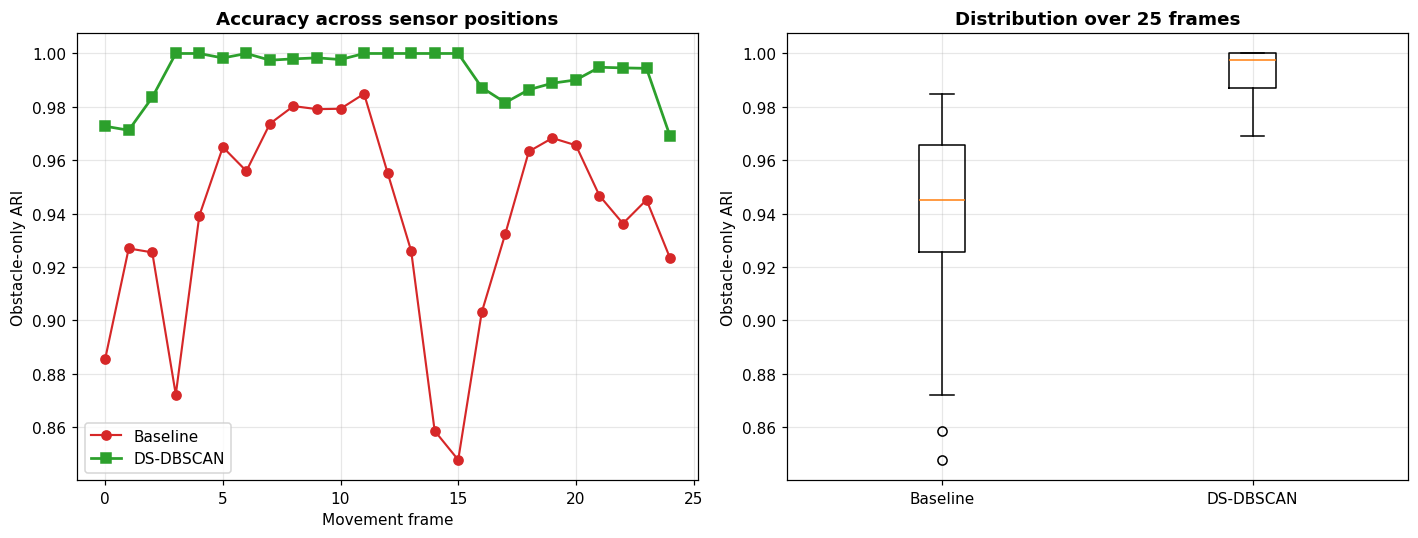

Saved: fig_exp7_movement.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(results_df))
axes[0].plot(x, results_df["ARI Baseline (obs)"], marker="o", lw=1.4,
             label="Baseline", color="#d62728")
axes[0].plot(x, results_df["ARI Kernel (obs)"], marker="s", lw=1.8,
             label="DS-DBSCAN", color="#2ca02c")
axes[0].set_xlabel("Movement frame"); axes[0].set_ylabel("Obstacle-only ARI")
axes[0].set_title("Accuracy across sensor positions", fontweight="bold")
axes[0].legend()

axes[1].boxplot([results_df["ARI Baseline (obs)"].dropna(),
                 results_df["ARI Kernel (obs)"].dropna()],
                labels=["Baseline", "DS-DBSCAN"])
axes[1].set_ylabel("Obstacle-only ARI")
axes[1].set_title("Distribution over 25 frames", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_exp7_movement.png", bbox_inches="tight")
plt.show()
print("Saved: fig_exp7_movement.png")


## 10. Export

In [11]:
results_df.to_csv("exp7_results_corrected.csv", index=False)
summary.to_csv("exp7_stats_summary.csv", index=False)
print("Saved: exp7_results_corrected.csv, exp7_stats_summary.csv\n")

for lbl, b, k in [("Obstacle ARI", "ARI Baseline (obs)", "ARI Kernel (obs)"),
                  ("Full ARI", "ARI Baseline (full)", "ARI Kernel (full)")]:
    win = (results_df[k] > results_df[b]).sum()
    print(f"{lbl:12s}: baseline {results_df[b].mean():.3f} -> kernel {results_df[k].mean():.3f}"
          f" | kernel wins {win}/{results_df[k].notna().sum()} frames")
print(f"Noise       : baseline {results_df['Baseline Noise'].mean():.1f}%"
      f" -> kernel {results_df['Kernel Noise'].mean():.1f}%")


Saved: exp7_results_corrected.csv, exp7_stats_summary.csv

Obstacle ARI: baseline 0.938 -> kernel 0.992 | kernel wins 25/25 frames
Full ARI    : baseline 0.781 -> kernel 0.805 | kernel wins 20/25 frames
Noise       : baseline 12.1% -> kernel 0.9%


## 11. How to Read Exp7



In [12]:
import numpy as np, pandas as pd
from scipy.stats import wilcoxon

def stat_row(label, base_col, kern_col, better):
    a = results_df[base_col].values          # baseline
    b = results_df[kern_col].values          # kernel
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    try:    _, p = wilcoxon(a, b)
    except Exception: p = np.nan
    return {"Metric": label, "Baseline": a.mean(), "DS-DBSCAN": b.mean(),
            "Δ": b.mean() - a.mean(), "p (Wilcoxon)": p, "n": len(a), "Better": better}

summary = pd.DataFrame([
    stat_row("Obstacle ARI", "ARI Baseline (obs)",  "ARI Kernel (obs)",  "higher"),
    stat_row("Full ARI",     "ARI Baseline (full)", "ARI Kernel (full)", "higher"),
    stat_row("Noise (%)",    "Baseline Noise",      "Kernel Noise",      "lower"),
    stat_row("Clusters",     "Baseline Clusters",   "Kernel Clusters",   "descriptive"),
])
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
summary.to_csv("exp3_summary_table.csv", index=False)

      Metric  Baseline  DS-DBSCAN       Δ  p (Wilcoxon)  n      Better
Obstacle ARI    0.9375     0.9922 0.05464      5.96e-08 25      higher
    Full ARI    0.7809     0.8048 0.02396       0.07098 25      higher
   Noise (%)     12.12        0.9  -11.22     1.225e-05 25       lower
    Clusters      7.12       7.92     0.8      0.001838 25 descriptive


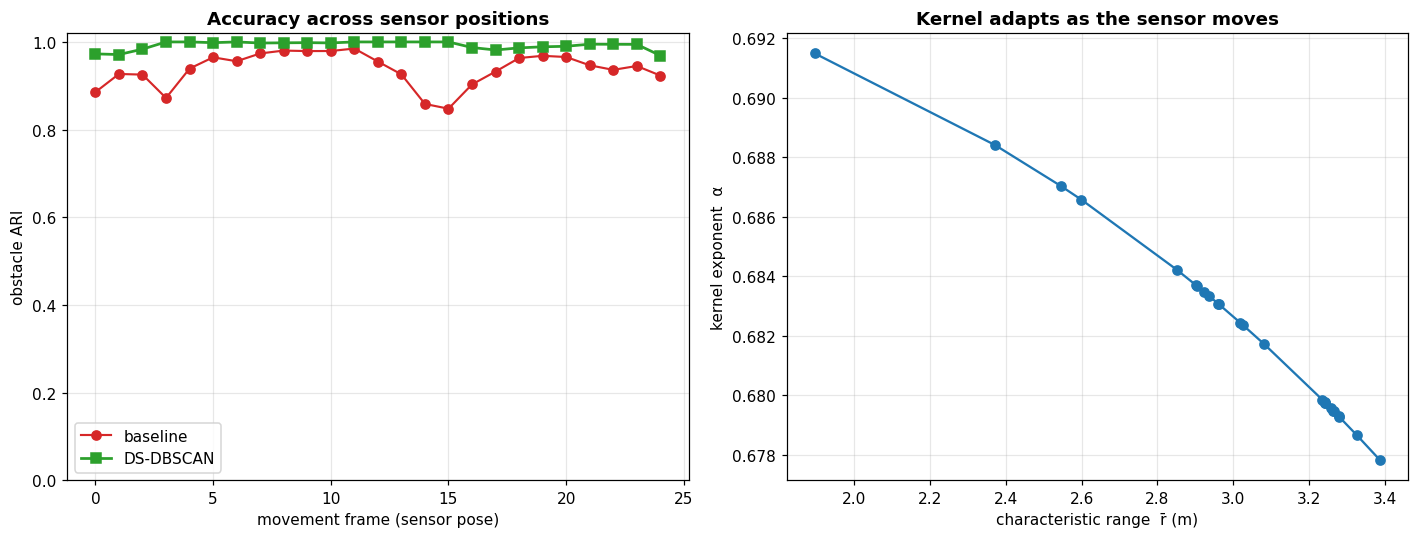

      Metric  Baseline  DS-DBSCAN       Δ  p (Wilcoxon)  n      Better
Obstacle ARI    0.9375     0.9922 0.05464      5.96e-08 25      higher
    Full ARI    0.7809     0.8048 0.02396       0.07098 25      higher
   Noise (%)     12.12        0.9  -11.22     1.225e-05 25       lower
    Clusters      7.12       7.92     0.8      0.001838 25 descriptive


In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results_df))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: obstacle ARI across the 25 poses
axes[0].plot(x, results_df["ARI Baseline (obs)"], "o-", color="#d62728", lw=1.4, label="baseline")
axes[0].plot(x, results_df["ARI Kernel (obs)"],   "s-", color="#2ca02c", lw=1.8, label="DS-DBSCAN")
axes[0].set_xlabel("movement frame (sensor pose)")
axes[0].set_ylabel("obstacle ARI")
axes[0].set_title("Accuracy across sensor positions", fontweight="bold")
axes[0].set_ylim(0, 1.02); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: the kernel adapting — alpha follows the characteristic range r_bar
ax2 = axes[1]
order = results_df.sort_values("Distance (m)")
ax2.plot(order["Distance (m)"], order["Alpha"], "o-", color="#1f77b4")
ax2.set_xlabel("characteristic range  r̄ (m)")
ax2.set_ylabel("kernel exponent  α")
ax2.set_title("Kernel adapts as the sensor moves", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_exp3_movement.png", dpi=300, bbox_inches="tight")
plt.show()
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

Pose 15: movement_pose_015 | 360 pts | r̄=3.26 m | α=0.679
Baseline:  8 clusters, 5.8% noise
DS-DBSCAN: 8 clusters, 0.0% noise


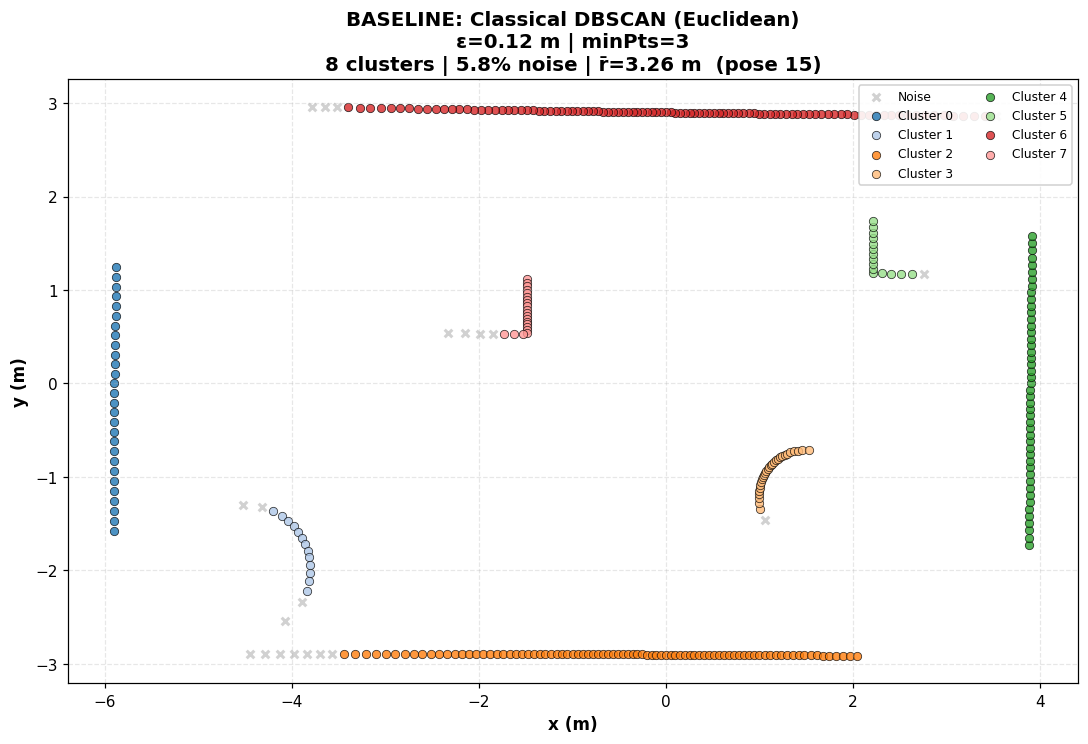

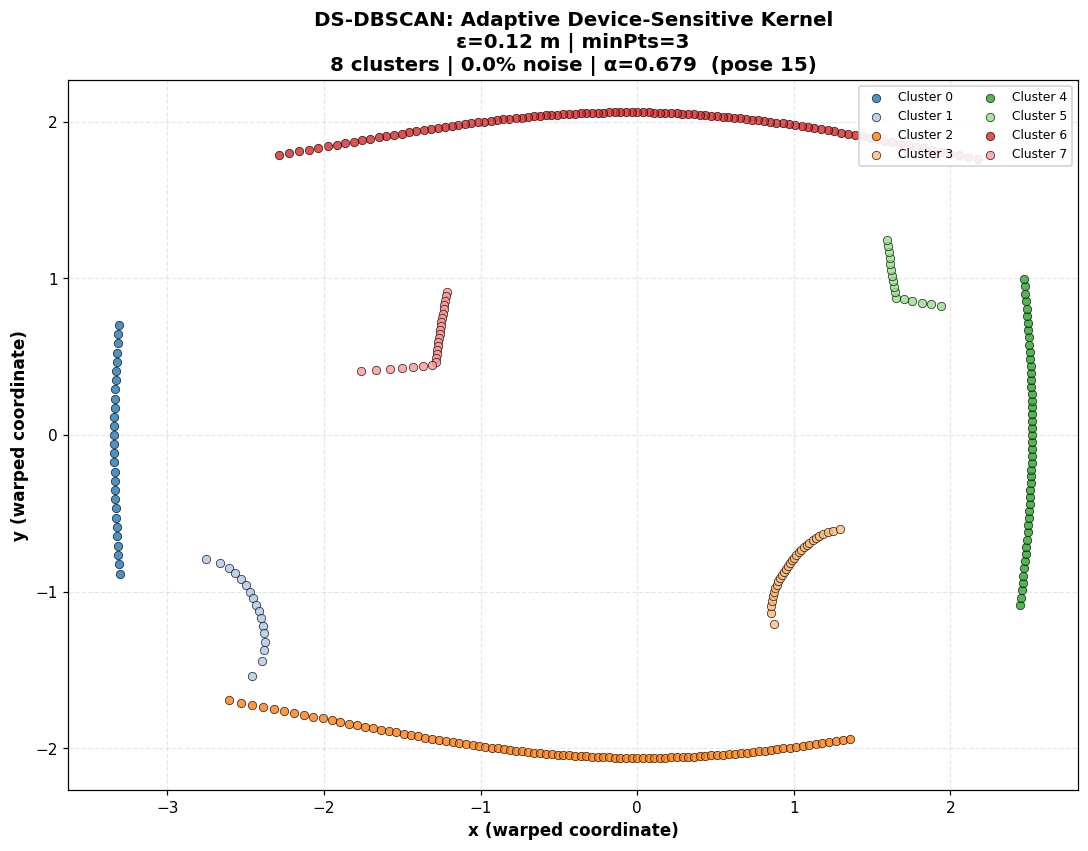

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def create_enhanced_colormap(n_colors=25):
    base = list(plt.cm.tab20(np.linspace(0, 1, 20)))
    if n_colors > 20:
        base += list(plt.cm.hsv(np.linspace(0, 0.9, n_colors - 20)))
    return base, np.array([0.7, 0.7, 0.7, 1.0])

# ===== CHOOSE THE POSE =====
POSE_INDEX = 15   # row index into results_df (0 to 24)
# ===========================

frame_id = results_df.iloc[POSE_INDEX]["Frame"]
df = master_df[master_df["environment_id"] == frame_id]
r_bar = df["distance_mm"].median() / 1000.0

# baseline + kernel (reuse the notebook's helpers)
pts_b = prepare_points_euclidean(df)
lab_b = run_dbscan(pts_b)
pts_k, alpha = prepare_points_kernel(df, r_bar, R0)
lab_k = run_dbscan(pts_k)

nb_, nk_     = n_clusters(lab_b), n_clusters(lab_k)
noi_b, noi_k = noise_pct(lab_b), noise_pct(lab_k)
colors, noise_color = create_enhanced_colormap(max(nb_, nk_) + 5)

print(f"Pose {POSE_INDEX}: {frame_id} | {len(df)} pts | r̄={r_bar:.2f} m | α={alpha:.3f}")
print(f"Baseline:  {nb_} clusters, {noi_b:.1f}% noise")
print(f"DS-DBSCAN: {nk_} clusters, {noi_k:.1f}% noise")

def plot_one(pts, lab, title, xlab, ylab, fname):
    fig, ax = plt.subplots(figsize=(10, 9))
    nm = lab == -1
    if nm.sum() > 0:
        ax.scatter(pts[nm,0], pts[nm,1], c=[noise_color], s=25, marker='x',
                   linewidths=2, label='Noise', alpha=0.6)
    for cid in sorted(set(lab)):
        if cid == -1: continue
        m = lab == cid
        ax.scatter(pts[m,0], pts[m,1], c=[colors[cid % len(colors)]], s=30,
                   label=f'Cluster {cid}', alpha=0.8, edgecolors='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel(xlab, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylab, fontsize=11, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    plt.tight_layout(); plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()

plot_one(pts_b, lab_b,
    f'BASELINE: Classical DBSCAN (Euclidean)\nε={FIXED_EPS} m | minPts={FIXED_MIN_SAMPS}\n'
    f'{nb_} clusters | {noi_b:.1f}% noise | r̄={r_bar:.2f} m  (pose {POSE_INDEX})',
    'x (m)', 'y (m)', f'exp3_pose{POSE_INDEX}_baseline.png')

plot_one(pts_k, lab_k,
    f'DS-DBSCAN: Adaptive Device-Sensitive Kernel\nε={FIXED_EPS} m | minPts={FIXED_MIN_SAMPS}\n'
    f'{nk_} clusters | {noi_k:.1f}% noise | α={alpha:.3f}  (pose {POSE_INDEX})',
    'x (warped coordinate)', 'y (warped coordinate)', f'exp3_pose{POSE_INDEX}_kernel.png')